이번 대회에서는 범주형 변수 전처리를 위해 Label Encoding과 for문을 사용했습니다.  

이는 train data로 fit한 Label Encoder로 test data를 transform할 경우,  

train data에는 속하지 않은 데이터가 test data에 있을 가능성이 있어 에러가 발생할 수 있기 때문입니다.  

이를 방지하기 위해 for문을 사용하여 예외적인 상황에 대처할 수 있도록 코드를 작성했습니다.  

참고해 주시길 바랍니다.  

# import / 라이브러리 호출

In [1]:
import numpy as np
import pandas as pd
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")


In [3]:
!pip3 install -qq scikit-learn

# Fixed RandomSeed / 랜덤시드 고정

In [2]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

seed_everything(42) # Seed 고정

# 폰트 설정


In [4]:
# ── Matplotlib 한글 폰트(나눔고딕) 설정: Google Colab 기준 ─────────────────────────
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 1) 나눔 폰트 설치 (Colab 전용 명령)
!apt-get update -qq
!apt-get install -qq fonts-nanum*

# 2) 폰트 등록: 파일 경로와 폰트 이름 매핑
fe = fm.FontEntry(
    fname="/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    name="NanumGothic"
)
fm.fontManager.ttflist.insert(0, fe)  # 폰트 목록 최상단에 삽입

# 3) Matplotlib 전역 설정
plt.rcParams.update({
    "font.size": 10,
    "font.family": "NanumGothic"
})
mpl.rcParams["axes.unicode_minus"] = False  # 음수 기호 깨짐 방지

# (선택) 정상 적용 확인
# from matplotlib.font_manager import FontProperties
# print("Resolved font path:", fm.findfont(FontProperties(family="NanumGothic")))

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

# Data Load / 데이터 불러오기

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [69]:
train = pd.read_csv('/content/drive/MyDrive/Project_stress/train.csv')
test = pd.read_csv('/content/drive/MyDrive/Project_stress/test.csv')

# 데이터 구조 파악

In [48]:
train.head()

,ID,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,smoke_status,medical_history,family_medical_history,sleep_pattern,edu_level,mean_working,stress_score
0,TRAIN_0000,F,72,161.49,58.47,279.84,165,100,143.35,0.87,moderate,ex-smoker,high blood pressure,diabetes,sleep difficulty,bachelors degree,NaN,0.63
1,TRAIN_0001,M,88,179.87,77.60,257.37,178,111,146.94,0.07,moderate,ex-smoker,NaN,diabetes,normal,graduate degree,NaN,0.83
2,TRAIN_0002,M,47,182.47,89.93,226.66,134,95,142.61,1.18,light,ex-smoker,NaN,NaN,normal,high school diploma,9.0,0.70
3,TRAIN_0003,M,69,185.78,68.63,206.74,158,92,137.26,0.48,intense,ex-smoker,high blood pressure,NaN,oversleeping,graduate degree,NaN,0.17
4,TRAIN_0004,F,81,164.63,71.53,255.92,171,116,129.37,0.34,moderate,ex-smoker,diabetes,diabetes,sleep difficulty,bachelors degree,NaN,0.36


In [49]:
train.describe() #기술통계량 확인

,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,mean_working,stress_score
count,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,1968.000000,3000.000000
mean,53.06800,168.585687,72.486680,233.910523,146.144333,95.504000,126.467720,0.933367,8.716972,0.482130
std,20.67207,9.351876,13.167222,24.333434,15.845310,9.895283,18.536844,0.444783,1.628944,0.288252
min,17.00000,141.130000,36.320000,148.810000,97.000000,60.000000,70.050000,-0.220000,4.000000,0.000000
25%,35.00000,161.800000,63.035000,216.927500,135.000000,89.000000,113.912500,0.560000,8.000000,0.230000
50%,53.00000,168.115000,71.240000,234.255000,146.000000,95.000000,126.555000,0.940000,9.000000,0.480000
75%,72.00000,175.352500,81.832500,250.377500,158.000000,102.000000,139.180000,1.300000,10.000000,0.730000
max,89.00000,195.280000,120.880000,313.350000,191.000000,124.000000,185.740000,2.000000,16.000000,1.000000


In [50]:
train.columns

Index(['ID', 'gender', 'age', 'height', 'weight', 'cholesterol',
       'systolic_blood_pressure', 'diastolic_blood_pressure', 'glucose',
       'bone_density', 'activity', 'smoke_status', 'medical_history',
       'family_medical_history', 'sleep_pattern', 'edu_level', 'mean_working',
       'stress_score'],
      dtype='object')

In [51]:
display(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   gender                    3000 non-null   object 
 2   age                       3000 non-null   int64  
 3   height                    3000 non-null   float64
 4   weight                    3000 non-null   float64
 5   cholesterol               3000 non-null   float64
 6   systolic_blood_pressure   3000 non-null   int64  
 7   diastolic_blood_pressure  3000 non-null   int64  
 8   glucose                   3000 non-null   float64
 9   bone_density              3000 non-null   float64
 10  activity                  3000 non-null   object 
 11  smoke_status              3000 non-null   object 
 12  medical_history           1711 non-null   object 
 13  family_medical_history    1514 non-null   object 
 14  sleep_pa

None

# **EDA**

In [70]:
# 필요없는 변수(ID) 제거
train = train.drop(columns=['ID'])
test  = test.drop(columns=['ID'])

train.columns

Index(['gender', 'age', 'height', 'weight', 'cholesterol',
       'systolic_blood_pressure', 'diastolic_blood_pressure', 'glucose',
       'bone_density', 'activity', 'smoke_status', 'medical_history',
       'family_medical_history', 'sleep_pattern', 'edu_level', 'mean_working',
       'stress_score'],
      dtype='object')

In [71]:
#결측치 확인
train.isna().sum().sort_values(ascending=False)

,0
family_medical_history,1486
medical_history,1289
mean_working,1032
edu_level,607
gender,0
age,0
height,0
weight,0
cholesterol,0
bone_density,0


In [72]:
train[['family_medical_history','medical_history','mean_working','edu_level']].head(10)

,family_medical_history,medical_history,mean_working,edu_level
0,diabetes,high blood pressure,NaN,bachelors degree
1,diabetes,NaN,NaN,graduate degree
2,NaN,NaN,9.0,high school diploma
3,NaN,high blood pressure,NaN,graduate degree
4,diabetes,diabetes,NaN,bachelors degree
5,NaN,NaN,NaN,high school diploma
6,diabetes,high blood pressure,NaN,graduate degree
7,NaN,NaN,NaN,high school diploma
8,NaN,high blood pressure,9.0,high school diploma
9,high blood pressure,heart disease,10.0,NaN


In [73]:
# 결과가 '0'인 것인지, 데이터가 없는것인지 알 수 없으므로 문자형은 unkown으로 처리
# 1. family_medical_history → unknown
train['family_medical_history'] = train['family_medical_history'].fillna('unknown')

# 2. medical_history → unknown
train['medical_history'] = train['medical_history'].fillna('unknown')

# 3. edu_level → unknown
train['edu_level'] = train['edu_level'].fillna('unknown')

# 4. mean_working → 결측 여부 feature 추가(근로시간이 0일수도 있기 때문)
train['mean_working_missing'] = train['mean_working'].isnull().astype(int)

# 5. mean_working → 중앙값으로 채우기
train['mean_working'] = train['mean_working'].fillna(train['mean_working'].median())

In [74]:
test['family_medical_history'] = test['family_medical_history'].fillna('unknown')

test['medical_history'] = test['medical_history'].fillna('unknown')

test['edu_level'] = test['edu_level'].fillna('unknown')

test['mean_working_missing'] = test['mean_working'].isnull().astype(int)

test['mean_working'] = test['mean_working'].fillna(test['mean_working'].median())

In [57]:
test.isna().sum().sort_values(ascending=False)

,0
gender,0
age,0
height,0
weight,0
cholesterol,0
systolic_blood_pressure,0
diastolic_blood_pressure,0
glucose,0
bone_density,0
activity,0


# 이상치 탐색


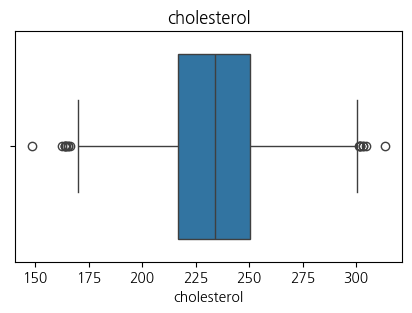

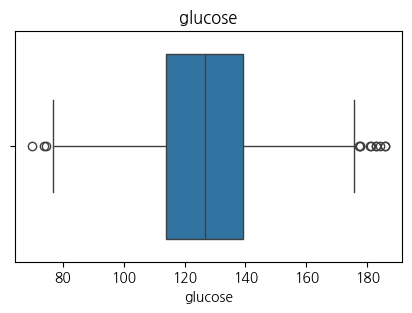

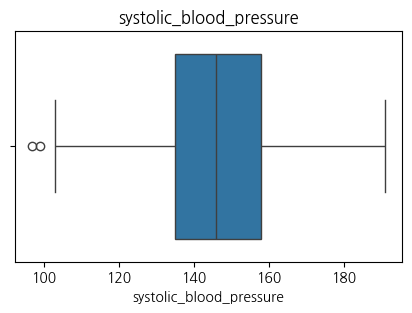

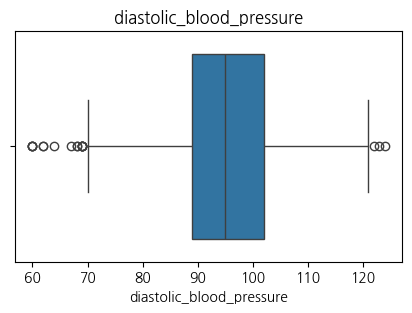

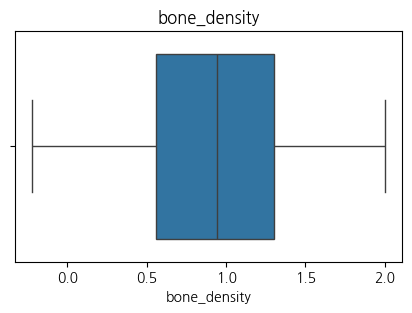

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'cholesterol',
    'glucose',
    'systolic_blood_pressure',
    'diastolic_blood_pressure',
    'bone_density'
]

for col in cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=train[col])
    plt.title(col)
    plt.show()

In [80]:
cols = [
    'cholesterol',
    'glucose',
    'systolic_blood_pressure',
    'diastolic_blood_pressure'
]

for col in cols:

    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train[(train[col] < lower) | (train[col] > upper)]

    print(f"\n{col}")
    print("Lower bound:", lower)
    print("Upper bound:", upper)
    print("Outlier count:", len(outliers))


cholesterol
Lower bound: 166.75250000000003
Upper bound: 300.5525
Outlier count: 17

glucose
Lower bound: 76.01124999999998
Upper bound: 177.08125
Outlier count: 13

systolic_blood_pressure
Lower bound: 100.5
Upper bound: 192.5
Outlier count: 2

diastolic_blood_pressure
Lower bound: 69.5
Upper bound: 121.5
Outlier count: 19


In [82]:
#이상치 범위와 개수 확인
cols = [
    'cholesterol',
    'glucose',
    'systolic_blood_pressure',
    'diastolic_blood_pressure'
]

outlier_summary = []

for col in cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((train[col] < lower) | (train[col] > upper)).sum()

    outlier_summary.append([col, Q1, Q3, IQR, lower, upper, outlier_count])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=['feature', 'Q1', 'Q3', 'IQR', 'lower_bound', 'upper_bound', 'outlier_count']
)

print(outlier_df)

                    feature        Q1        Q3      IQR  lower_bound  \
0               cholesterol  216.9275  250.3775  33.4500    166.75250   
1                   glucose  113.9125  139.1800  25.2675     76.01125   
2   systolic_blood_pressure  135.0000  158.0000  23.0000    100.50000   
3  diastolic_blood_pressure   89.0000  102.0000  13.0000     69.50000   

   upper_bound  outlier_count  
0    300.55250             17  
1    177.08125             13  
2    192.50000              2  
3    121.50000             19  


In [83]:
clip_cols = [
    'cholesterol',
    'glucose',
    'systolic_blood_pressure',
    'diastolic_blood_pressure'
]

# train 기준 범위 계산 + train 클리핑
train_clipped = train.copy()
bounds = {}

for col in clip_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train_clipped[col] = train_clipped[col].clip(lower, upper)
    bounds[col] = (lower, upper)

# 같은 범위를 test에도 적용
test_clipped = test.copy()

for col in clip_cols:
    lower, upper = bounds[col]
    test_clipped[col] = test_clipped[col].clip(lower, upper)

print("이상치 클리핑 완료")
print(bounds)

이상치 클리핑 완료
{'cholesterol': (np.float64(166.75250000000003), np.float64(300.5525)), 'glucose': (np.float64(76.01124999999998), np.float64(177.08125)), 'systolic_blood_pressure': (np.float64(100.5), np.float64(192.5)), 'diastolic_blood_pressure': (np.float64(69.5), np.float64(121.5))}


In [84]:
def iqr_clip(df, columns):
    df = df.copy()

    bounds = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower, upper)
        bounds[col] = (lower, upper)

    return df, bounds

## **CatBoost (Baseline)**

이번 데이터에 범주형 변수가 많기 때문에 범주형 변수를 효과적으로 처리할 수 있는 CatBoost를 baseline 모델로 선택했습니다. 데이터에서 어떤 변수가 중요한지 파악하기 위해 먼저 baseline 모델을 학습하여 feature importance를 확인하고, 이후 중요한 변수들을 중심으로 파생변수를 생성하여 모델의 예측 성능을 개선하고자 했습니다.

In [75]:
#X/y 분리

X = train.drop('stress_score', axis=1)
y = train['stress_score']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [76]:
!pip install catboost

In [85]:
#범주형컬럼 확인
cat_features = [
    'gender',
    'activity',
    'smoke_status',
    'medical_history',
    'family_medical_history',
    'sleep_pattern',
    'edu_level'
]
# CatBoost

from catboost import CatBoostRegressor

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=200
)

# 모델 학습
model.fit(
    X_train, y_train,
    eval_set=(X_valid, y_valid),
    cat_features=cat_features,
    use_best_model=True
)

0:	learn: 0.2894660	test: 0.2805418	best: 0.2805418 (0)	total: 17.3ms	remaining: 17.3s
200:	learn: 0.2528960	test: 0.2676852	best: 0.2676001 (196)	total: 1.2s	remaining: 4.75s
400:	learn: 0.2198622	test: 0.2594229	best: 0.2594229 (400)	total: 2.49s	remaining: 3.72s
600:	learn: 0.1933019	test: 0.2546729	best: 0.2545922 (598)	total: 3.77s	remaining: 2.5s
800:	learn: 0.1711571	test: 0.2511279	best: 0.2511279 (800)	total: 5.06s	remaining: 1.26s
999:	learn: 0.1536106	test: 0.2482027	best: 0.2481511 (996)	total: 6.35s	remaining: 0us

bestTest = 0.2481511182
bestIteration = 996

Shrink model to first 997 iterations.


CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=200)

In [86]:
# 검증 성능 확인
valid_pred = model.predict(X_valid)
rmse = np.sqrt(mean_squared_error(y_valid, valid_pred))
print("Validation RMSE:", rmse)

Validation RMSE: 0.24815111837105386


CatBoost 원본 ver. Validation RMSE: 0.24815111837105386

CatBoost 이상치 클리핑 ver. Validation RMSE: 0.24815111837105386

# feature importance 분석

In [87]:
#각 변수의 중요도 확인
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.get_feature_importance()
})

feature_importance = feature_importance.sort_values(
    by='importance',
    ascending=False
)

print(feature_importance)

                     feature  importance
4                cholesterol   11.747477
2                     height   11.353917
3                     weight    9.734181
5    systolic_blood_pressure    9.286068
7                    glucose    8.939914
8               bone_density    8.083276
6   diastolic_blood_pressure    7.305399
1                        age    6.043929
11           medical_history    4.344303
14                 edu_level    4.176347
10              smoke_status    3.942725
9                   activity    3.935456
12    family_medical_history    3.618795
15              mean_working    3.504734
13             sleep_pattern    3.415613
0                     gender    0.363372
16      mean_working_missing    0.204495


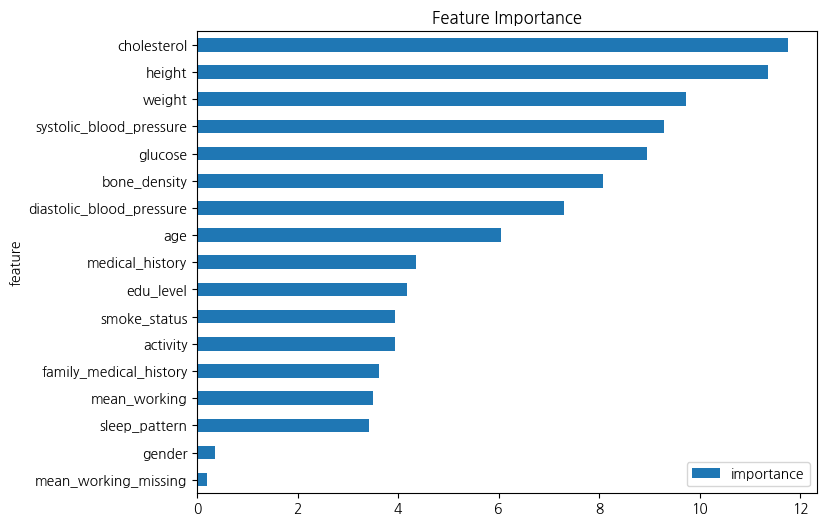

In [88]:
import matplotlib.pyplot as plt

feature_importance.sort_values(
    by='importance'
).plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Importance")
plt.show()

신체 건강 관련변수(cholesterol, heigth, weight, SBP, DBP, age)가 스트레스 예측에 가장 큰 영향을 미치는 것으로 나타났습니다.
또한 height와 weight가 중요 변수로 나타나 BMI와 같은 파생변수를 생성할 필요성을 확인했습니다.
이러한 분석을 기반으로 추가적인 feature engineering을 통해 RMSE를 개선하고자 합니다.

생활습관 변수(medical history, edu level, smoke status, activity, family medical history, mean working, sleep patternl)은 보조적인 역할을 한단다.

gender, mean_working missing은 거의 영향이 없어 보인다.

# 파생변수 생성

In [89]:
def make_features(df):
    df = df.copy()

    # 1. BMI
    df['BMI'] = df['weight'] / ((df['height'] / 100) ** 2)

    # 2. 혈압 평균
    df['bp_mean'] = (
        df['systolic_blood_pressure'] + df['diastolic_blood_pressure']
    ) / 2

    # 3. 맥압
    df['pulse_pressure'] = (
        df['systolic_blood_pressure'] - df['diastolic_blood_pressure']
    )

    # 4. 심혈관 스트레스 지수
    df['cardio_stress'] = df['bp_mean'] * (df['age'] / 50)

    # 5. 대사 위험 점수
    df['metabolic_risk'] = df['cholesterol'] + df['glucose']

    # 6. BMI + 나이 상호작용
    df['bmi_age_stress'] = df['BMI'] * (df['age'] / 50)

    # 7 스트레스 누적 개념(스트레스는 누적부담으로 작용)
    df['allostatic_load'] = (
    df['bp_mean'] + df['glucose'] + df['cholesterol'] + df['BMI']
    )

    # 8. 생활습관(수면, 활동, 스트레스는 강하게 연결)
    df['low_activity_flag'] = (df['activity'] == 'light').astype(int)
    df['sleep_problem_flag'] = (df['sleep_pattern'] != 'normal').astype(int)
    df['smoker_flag'] = (df['smoke_status'] == 'current-smoker').astype(int)

    df['lifestyle_burden'] = (
        df['low_activity_flag'] +
        df['sleep_problem_flag'] +
        df['smoker_flag']
    )

    # 9. 나이 + 대사 상호작용(스트레스 반응은 나이에 따라 달라짐)
    df['age_metabolic'] = df['age'] * df['metabolic_risk']

    # 10. 추가 상호작용
    df['bmi_glucose'] = df['BMI'] * df['glucose']

    return df

In [97]:
#파생변수 포함하여 CatBoost

train_fe = make_features(train)
test_fe = make_features(test)

target_col = 'stress_score'

drop_cols = ['ID', target_col]
features = [col for col in train_fe.columns if col not in drop_cols]

X = train_fe[features]
y = train_fe[target_col]
X_test = test_fe[features]

cat_features = [
    'gender',
    'medical_history',
    'family_medical_history',
    'smoke_status',
    'activity',
    'sleep_pattern',
    'edu_level'
]

cat_features = [col for col in cat_features if col in X.columns]
print("cat_features:", cat_features)

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

cat_features: ['gender', 'medical_history', 'family_medical_history', 'smoke_status', 'activity', 'sleep_pattern', 'edu_level']


In [98]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True
)

val_pred = model.predict(X_val)
rmse = np.sqrt(mean_squared_error(y_val, val_pred))
print(f'Validation RMSE: {rmse:.6f}')

#파생변수 추가 후 RMSE 0.248151-> 0.244694

0:	learn: 0.2895220	test: 0.2805425	best: 0.2805425 (0)	total: 11.5ms	remaining: 11.4s
100:	learn: 0.2666779	test: 0.2709841	best: 0.2709841 (99)	total: 785ms	remaining: 6.98s
200:	learn: 0.2477305	test: 0.2667651	best: 0.2667651 (200)	total: 1.6s	remaining: 6.37s
300:	learn: 0.2280587	test: 0.2632220	best: 0.2632220 (300)	total: 2.44s	remaining: 5.67s
400:	learn: 0.2109631	test: 0.2592274	best: 0.2592274 (400)	total: 3.29s	remaining: 4.91s
500:	learn: 0.1959856	test: 0.2559743	best: 0.2559743 (500)	total: 4.12s	remaining: 4.1s
600:	learn: 0.1811312	test: 0.2518990	best: 0.2518990 (600)	total: 4.95s	remaining: 3.29s
700:	learn: 0.1679324	test: 0.2488765	best: 0.2488765 (700)	total: 5.79s	remaining: 2.47s
800:	learn: 0.1569105	test: 0.2471133	best: 0.2470115 (797)	total: 6.71s	remaining: 1.67s
900:	learn: 0.1488185	test: 0.2458660	best: 0.2458398 (899)	total: 8.5s	remaining: 934ms
999:	learn: 0.1404757	test: 0.2447200	best: 0.2446944 (998)	total: 10.3s	remaining: 0us

bestTest = 0.24469

In [99]:
# Feature Importance 확인

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

print(feature_importance)

                     feature  importance
2                     height    7.404185
4                cholesterol    7.037857
7                    glucose    5.808232
8               bone_density    5.763106
3                     weight    5.731224
17                       BMI    5.486900
29               bmi_glucose    4.632309
6   diastolic_blood_pressure    4.538605
19            pulse_pressure    4.461114
21            metabolic_risk    4.236248
23           allostatic_load    4.173241
5    systolic_blood_pressure    3.603541
12    family_medical_history    3.603370
18                   bp_mean    3.307617
15              mean_working    3.206569
22            bmi_age_stress    3.151465
14                 edu_level    2.960032
11           medical_history    2.825450
9                   activity    2.679509
20             cardio_stress    2.659505
28             age_metabolic    2.534474
27          lifestyle_burden    2.185796
10              smoke_status    2.102040
13             s

# 파생변수 검증

In [100]:
# Permutation Importance 확인
# : 변수를 망가뜨렸을 때 성능이 얼마나 떨어지는지
# feature importance : 모델이 얼마나 자주 사용했는지를 의미
# permutation importance : 실제 성능에 얼마나 영향을 주는지 알 수 있다.
# 음수는 성능을 떨어뜨리는 변수이므로 삭제 확정. 하위권은 삭제 후보(영향 거의 없음)
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_val,
    y_val,
    n_repeats=10,
    random_state=42
)

perm_importance_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

print(perm_importance_df)

                     feature  importance
15              mean_working    0.070472
8               bone_density    0.058584
2                     height    0.050564
4                cholesterol    0.038979
29               bmi_glucose    0.036445
6   diastolic_blood_pressure    0.034387
7                    glucose    0.030132
17                       BMI    0.029588
18                   bp_mean    0.028695
3                     weight    0.024754
22            bmi_age_stress    0.022960
14                 edu_level    0.017597
19            pulse_pressure    0.017190
23           allostatic_load    0.015792
20             cardio_stress    0.015559
10              smoke_status    0.014424
5    systolic_blood_pressure    0.013173
21            metabolic_risk    0.012122
12    family_medical_history    0.011892
13             sleep_pattern    0.011848
1                        age    0.010863
27          lifestyle_burden    0.009994
11           medical_history    0.009976
9               

In [101]:
#feature 정리
base_rmse = rmse
print("기준 RMSE:", base_rmse)

기준 RMSE: 0.2446944197738113


In [102]:
check_features = [
    'smoker_flag',
    'mean_working_missing',
    'gender',
    'low_activity_flag',
    'sleep_problem_flag',
    'lifestyle_burden',
    'age_metabolic'
]

results = []

for col in check_features:
    temp_features = [f for f in X.columns if f != col]

    X_train_temp = X_train[temp_features]
    X_val_temp = X_val[temp_features]

    temp_cat_features = [c for c in cat_features if c in temp_features]

    temp_model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0
    )

    temp_model.fit(
        X_train_temp, y_train,
        cat_features=temp_cat_features,
        eval_set=(X_val_temp, y_val),
        use_best_model=True
    )

    pred = temp_model.predict(X_val_temp)
    temp_rmse = np.sqrt(mean_squared_error(y_val, pred))

    results.append([col, temp_rmse, temp_rmse - base_rmse])

result_df = pd.DataFrame(results, columns=['removed_feature', 'rmse', 'diff'])
print(result_df.sort_values('rmse'))

        removed_feature      rmse      diff
4    sleep_problem_flag  0.243576 -0.001118
5      lifestyle_burden  0.244153 -0.000541
3     low_activity_flag  0.244445 -0.000249
0           smoker_flag  0.244592 -0.000102
6         age_metabolic  0.245436  0.000741
2                gender  0.245624  0.000930
1  mean_working_missing  0.246620  0.001926


<diff 해석법>

diff < 0 : 삭제 후 RMSE가 더 좋아짐
→ 삭제 추천

diff > 0 : 삭제 후 RMSE가 나빠짐
→ 유지 추천

diff ≈ 0 : 차이 거의 없음
→ 단순화를 위해 삭제 가능

예를 들어:

diff = -0.0008 → 삭제하는 게 좋음

diff = +0.0015 → 유지해야 함

diff = +0.0000 → 없어도 됨

In [103]:
#삭제 확정
drop_features = [
    'sleep_problem_flag',
    'lifestyle_burden',
    'low_activity_flag',
    'smoker_flag'
]

In [106]:
#CatBoost 다시 학습

features_v2 = [f for f in X.columns if f not in drop_features]

X_v2 = X[features_v2]
X_test_v2 = X_test[features_v2]

print("삭제 후 feature 개수:", len(features_v2))
print(features_v2)

from sklearn.model_selection import train_test_split

X_train_v2, X_val_v2, y_train_v2, y_val_v2 = train_test_split(
    X_v2, y,
    test_size=0.2,
    random_state=42
)

cat_features_v2 = [c for c in cat_features if c in X_train_v2.columns]
print("cat_features_v2:", cat_features_v2)

from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

model_v2 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

model_v2.fit(
    X_train_v2, y_train_v2,
    cat_features=cat_features_v2,
    eval_set=(X_val_v2, y_val_v2),
    use_best_model=True
)

val_pred_v2 = model_v2.predict(X_val_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_val_v2, val_pred_v2))
print(f'Validation RMSE (v2): {rmse_v2:.6f}')

삭제 후 feature 개수: 26
['gender', 'age', 'height', 'weight', 'cholesterol', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'glucose', 'bone_density', 'activity', 'smoke_status', 'medical_history', 'family_medical_history', 'sleep_pattern', 'edu_level', 'mean_working', 'mean_working_missing', 'BMI', 'bp_mean', 'pulse_pressure', 'cardio_stress', 'metabolic_risk', 'bmi_age_stress', 'allostatic_load', 'age_metabolic', 'bmi_glucose']
cat_features_v2: ['gender', 'medical_history', 'family_medical_history', 'smoke_status', 'activity', 'sleep_pattern', 'edu_level']
0:	learn: 0.2893779	test: 0.2807281	best: 0.2807281 (0)	total: 10.8ms	remaining: 10.8s
100:	learn: 0.2679031	test: 0.2718730	best: 0.2718730 (100)	total: 831ms	remaining: 7.4s
200:	learn: 0.2494601	test: 0.2675711	best: 0.2675711 (200)	total: 1.68s	remaining: 6.67s
300:	learn: 0.2285629	test: 0.2635860	best: 0.2635860 (300)	total: 2.56s	remaining: 5.94s
400:	learn: 0.2122809	test: 0.2606782	best: 0.2606782 (400)	total: 3.46s	re

In [107]:
#이전 점수와 비교
print(f'기존 RMSE: {rmse:.6f}')
print(f'새 RMSE:   {rmse_v2:.6f}')
print(f'차이:      {rmse_v2 - rmse:.6f}')

기존 RMSE: 0.244694
새 RMSE:   0.246385
차이:      0.001690


In [108]:
# RMSE가 떨어졌으므로 개별 제거 테스트
test_features = [
    'sleep_problem_flag',
    'lifestyle_burden',
    'low_activity_flag',
    'smoker_flag'
]

results = []

for col in test_features:
    temp_features = [f for f in X.columns if f != col]

    X_train_temp = X_train[temp_features]
    X_val_temp = X_val[temp_features]

    temp_cat_features = [c for c in cat_features if c in temp_features]

    temp_model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0
    )

    temp_model.fit(
        X_train_temp, y_train,
        cat_features=temp_cat_features,
        eval_set=(X_val_temp, y_val),
        use_best_model=True
    )

    pred = temp_model.predict(X_val_temp)
    temp_rmse = np.sqrt(mean_squared_error(y_val, pred))

    results.append([col, temp_rmse, temp_rmse - rmse])

import pandas as pd
result_df = pd.DataFrame(results, columns=['removed_feature', 'rmse', 'diff'])
print(result_df.sort_values('rmse'))

      removed_feature      rmse      diff
0  sleep_problem_flag  0.243576 -0.001118
1    lifestyle_burden  0.244153 -0.000541
2   low_activity_flag  0.244445 -0.000249
3         smoker_flag  0.244592 -0.000102


In [109]:
#diff < 0→ 그 조합은 삭제하는 게 좋음
#diff > 0→ 그 조합은 삭제하면 안 됨

from itertools import combinations
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

base_rmse = rmse  # 현재 전체 feature 모델의 RMSE = 0.244694

candidate_features = [
    'sleep_problem_flag',
    'lifestyle_burden',
    'low_activity_flag',
    'smoker_flag'
]

combo_results = []

for r in [2, 3, 4]:
    for combo in combinations(candidate_features, r):
        temp_features = [f for f in X.columns if f not in combo]

        X_train_temp = X_train[temp_features]
        X_val_temp = X_val[temp_features]

        temp_cat_features = [c for c in cat_features if c in temp_features]

        temp_model = CatBoostRegressor(
            iterations=1000,
            learning_rate=0.05,
            depth=6,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=42,
            verbose=0
        )

        temp_model.fit(
            X_train_temp, y_train,
            cat_features=temp_cat_features,
            eval_set=(X_val_temp, y_val),
            use_best_model=True
        )

        pred = temp_model.predict(X_val_temp)
        temp_rmse = np.sqrt(mean_squared_error(y_val, pred))

        combo_results.append([
            combo,
            temp_rmse,
            temp_rmse - base_rmse
        ])

combo_df = pd.DataFrame(combo_results, columns=['removed_features', 'rmse', 'diff'])
print(combo_df.sort_values('rmse'))

                                     removed_features      rmse      diff
5                    (low_activity_flag, smoker_flag)  0.243456 -0.001238
4                     (lifestyle_burden, smoker_flag)  0.244905  0.000211
2                   (sleep_problem_flag, smoker_flag)  0.245200  0.000505
0              (sleep_problem_flag, lifestyle_burden)  0.245289  0.000595
8   (sleep_problem_flag, low_activity_flag, smoker...  0.245352  0.000658
3               (lifestyle_burden, low_activity_flag)  0.245720  0.001026
7   (sleep_problem_flag, lifestyle_burden, smoker_...  0.245915  0.001221
10  (sleep_problem_flag, lifestyle_burden, low_act...  0.246385  0.001690
9   (lifestyle_burden, low_activity_flag, smoker_f...  0.246844  0.002149
1             (sleep_problem_flag, low_activity_flag)  0.246870  0.002176
6   (sleep_problem_flag, lifestyle_burden, low_act...  0.249923  0.005228


In [110]:
drop_features_final = ['low_activity_flag', 'smoker_flag']

features_v3 = [f for f in X.columns if f not in drop_features_final]

X_v3 = X[features_v3]
X_test_v3 = X_test[features_v3]

X_train_v3, X_val_v3, y_train_v3, y_val_v3 = train_test_split(
    X_v3, y,
    test_size=0.2,
    random_state=42
)

cat_features_v3 = [c for c in cat_features if c in X_train_v3.columns]

model_v3 = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=100
)

model_v3.fit(
    X_train_v3, y_train_v3,
    cat_features=cat_features_v3,
    eval_set=(X_val_v3, y_val_v3),
    use_best_model=True
)

val_pred_v3 = model_v3.predict(X_val_v3)
rmse_v3 = np.sqrt(mean_squared_error(y_val_v3, val_pred_v3))

print(f'기존 RMSE: {rmse:.6f}')
print(f'새 RMSE:   {rmse_v3:.6f}')
print(f'차이:      {rmse_v3 - rmse:.6f}')

0:	learn: 0.2894663	test: 0.2805551	best: 0.2805551 (0)	total: 9.75ms	remaining: 9.74s
100:	learn: 0.2679049	test: 0.2714163	best: 0.2714163 (100)	total: 840ms	remaining: 7.47s
200:	learn: 0.2478464	test: 0.2666315	best: 0.2666315 (200)	total: 1.69s	remaining: 6.7s
300:	learn: 0.2279505	test: 0.2611141	best: 0.2611141 (300)	total: 2.55s	remaining: 5.92s
400:	learn: 0.2112087	test: 0.2574624	best: 0.2574624 (400)	total: 3.42s	remaining: 5.1s
500:	learn: 0.1959461	test: 0.2541485	best: 0.2541485 (500)	total: 5.18s	remaining: 5.16s
600:	learn: 0.1831640	test: 0.2519395	best: 0.2519239 (589)	total: 7.01s	remaining: 4.65s
700:	learn: 0.1706853	test: 0.2485978	best: 0.2485978 (700)	total: 8.34s	remaining: 3.56s
800:	learn: 0.1595956	test: 0.2468328	best: 0.2468259 (798)	total: 9.24s	remaining: 2.3s
900:	learn: 0.1492040	test: 0.2451009	best: 0.2451009 (900)	total: 10.1s	remaining: 1.11s
999:	learn: 0.1401074	test: 0.2434562	best: 0.2434562 (999)	total: 11s	remaining: 0us

bestTest = 0.243456

In [111]:
#hleight 제거(BMI에 중복)
test_features = ['height']

results = []

for col in test_features:
    temp_features = [f for f in X.columns if f != col]

    X_train_temp = X_train[temp_features]
    X_val_temp = X_val[temp_features]

    temp_cat_features = [c for c in cat_features if c in temp_features]

    temp_model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0
    )

    temp_model.fit(
        X_train_temp, y_train,
        cat_features=temp_cat_features,
        eval_set=(X_val_temp, y_val),
        use_best_model=True
    )

    pred = temp_model.predict(X_val_temp)
    temp_rmse = np.sqrt(mean_squared_error(y_val, pred))

    results.append([col, temp_rmse, temp_rmse - rmse])

print(pd.DataFrame(results, columns=['removed_feature', 'rmse', 'diff']))

# diff > 0유지 결정

  removed_feature      rmse      diff
0          height  0.245318  0.000624


In [112]:
#중복되는 파생변수 중 필요한 것만 남기기
test_features = [
    'metabolic_risk',
    'allostatic_load',
    'cardio_stress',
    'bp_mean',
    'bmi_age_stress',
    'age_metabolic'
]

results = []

for col in test_features:
    temp_features = [f for f in X.columns if f != col]

    X_train_temp = X_train[temp_features]
    X_val_temp = X_val[temp_features]

    temp_cat_features = [c for c in cat_features if c in temp_features]

    temp_model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0
    )

    temp_model.fit(
        X_train_temp, y_train,
        cat_features=temp_cat_features,
        eval_set=(X_val_temp, y_val),
        use_best_model=True
    )

    pred = temp_model.predict(X_val_temp)
    temp_rmse = np.sqrt(mean_squared_error(y_val, pred))

    results.append([col, temp_rmse, temp_rmse - rmse])

result_df = pd.DataFrame(results, columns=['removed_feature', 'rmse', 'diff'])
print(result_df.sort_values('rmse'))

# allostatic_load diff : 0.000040 거의 변화 없으므로 제거

   removed_feature      rmse      diff
1  allostatic_load  0.244734  0.000040
2    cardio_stress  0.245339  0.000644
5    age_metabolic  0.245436  0.000741
0   metabolic_risk  0.245776  0.001081
4   bmi_age_stress  0.245842  0.001147
3          bp_mean  0.245981  0.001287


In [115]:
#중복 제거를 위한 metabolic 그룹 테스트(단일 vs 파생)
test_groups = [
    ['metabolic_risk'],
    ['glucose'],
    ['cholesterol'],
    ['metabolic_risk', 'glucose'],
    ['metabolic_risk', 'cholesterol'],
    ['glucose', 'cholesterol']
]

results = []

for group in test_groups:
    temp_features = [f for f in X.columns if f not in group]

    X_train_temp = X_train[temp_features]
    X_val_temp = X_val[temp_features]

    temp_cat_features = [c for c in cat_features if c in temp_features]

    temp_model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0
    )

    temp_model.fit(
        X_train_temp, y_train,
        cat_features=temp_cat_features,
        eval_set=(X_val_temp, y_val),
        use_best_model=True
    )

    pred = temp_model.predict(X_val_temp)
    temp_rmse = np.sqrt(mean_squared_error(y_val, pred))

    results.append([group, temp_rmse, temp_rmse - rmse])

pd.DataFrame(results, columns=['removed', 'rmse', 'diff']).sort_values('rmse')
# metabolic_risk, glucose 삭제

,removed,rmse,diff
3,"[metabolic_risk, glucose]",0.244416,-0.000278
1,[glucose],0.245022,0.000328
0,[metabolic_risk],0.245776,0.001081
4,"[metabolic_risk, cholesterol]",0.247930,0.003235
5,"[glucose, cholesterol]",0.247934,0.003239
2,[cholesterol],0.247969,0.003275


In [116]:
#혈압 그룹 테스트
test_groups = [
    ['bp_mean'],
    ['pulse_pressure'],
    ['systolic_blood_pressure', 'diastolic_blood_pressure'],
    ['bp_mean', 'pulse_pressure'],
    ['bp_mean', 'systolic_blood_pressure'],
    ['bp_mean', 'diastolic_blood_pressure']
]

results = []

for group in test_groups:
    temp_features = [f for f in X.columns if f not in group]

    X_train_temp = X_train[temp_features]
    X_val_temp = X_val[temp_features]

    temp_cat_features = [c for c in cat_features if c in temp_features]

    temp_model = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0
    )

    temp_model.fit(
        X_train_temp, y_train,
        cat_features=temp_cat_features,
        eval_set=(X_val_temp, y_val),
        use_best_model=True
    )

    pred = temp_model.predict(X_val_temp)
    temp_rmse = np.sqrt(mean_squared_error(y_val, pred))

    results.append([group, temp_rmse, temp_rmse - rmse])

pd.DataFrame(results, columns=['removed', 'rmse', 'diff']).sort_values('rmse')
# SBP, DBP 제거

,removed,rmse,diff
2,"[systolic_blood_pressure, diastolic_blood_pres...",0.244188,-0.000506
0,[bp_mean],0.245981,0.001287
1,[pulse_pressure],0.246003,0.001309
3,"[bp_mean, pulse_pressure]",0.246648,0.001954
5,"[bp_mean, diastolic_blood_pressure]",0.246799,0.002105
4,"[bp_mean, systolic_blood_pressure]",0.247476,0.002782


# 최종 Feature 적용

In [117]:
drop_features_final = [
    'low_activity_flag',
    'smoker_flag',
    'allostatic_load',
    'metabolic_risk',
    'glucose',
    'systolic_blood_pressure',
    'diastolic_blood_pressure'
]

features_final = [f for f in X.columns if f not in drop_features_final]

X_final = X[features_final]
X_test_final = X_test[features_final]

print("최종 feature 개수:", len(features_final))

최종 feature 개수: 23


In [120]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# ======================
# 1. OOF 준비(KFold)
# ======================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cat_oof = np.zeros(len(X_final))
cat_test_preds = np.zeros(len(X_test_final))

# ======================
# 2. OOF 학습
# ======================
for fold, (train_idx, val_idx) in enumerate(kf.split(X_final, y), 1):
    X_tr = X_final.iloc[train_idx]
    X_va = X_final.iloc[val_idx]
    y_tr = y.iloc[train_idx]
    y_va = y.iloc[val_idx]

    cat_model = CatBoostRegressor(
        iterations=1200,
        learning_rate=0.04,
        depth=6,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        verbose=0
    )

    cat_model.fit(
        X_tr, y_tr,
        cat_features=cat_features_f,
        eval_set=(X_va, y_va),
        use_best_model=True
    )

    cat_oof[val_idx] = cat_model.predict(X_va)
    cat_test_preds += cat_model.predict(X_test_final) / kf.n_splits

    fold_rmse = np.sqrt(mean_squared_error(y_va, cat_oof[val_idx]))
    print(f"[CatBoost] Fold {fold} RMSE: {fold_rmse:.6f}")

# ======================
# 3. 전체 OOF 성능
# ======================
cat_rmse = np.sqrt(mean_squared_error(y, cat_oof))
print(f"\n[CatBoost] OOF RMSE: {cat_rmse:.6f}")

[CatBoost] Fold 1 RMSE: 0.244587
[CatBoost] Fold 2 RMSE: 0.258654
[CatBoost] Fold 3 RMSE: 0.259463
[CatBoost] Fold 4 RMSE: 0.266539
[CatBoost] Fold 5 RMSE: 0.259576

[CatBoost] OOF RMSE: 0.257864


# 인코딩

In [125]:
def encode_with_unknown(train_df, valid_df, test_df, cat_cols):
    train_df = train_df.copy()
    valid_df = valid_df.copy()
    test_df = test_df.copy()

    for col in cat_cols:
        train_vals = train_df[col].astype(str).fillna('unknown')
        valid_vals = valid_df[col].astype(str).fillna('unknown')
        test_vals = test_df[col].astype(str).fillna('unknown')

        mapping = {v: i for i, v in enumerate(train_vals.unique())}

        train_df[col] = train_vals.map(mapping).astype(int)
        valid_df[col] = valid_vals.map(mapping).fillna(-1).astype(int)
        test_df[col] = test_vals.map(mapping).fillna(-1).astype(int)

    return train_df, valid_df, test_df

# LightGBM

In [143]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor

# KFold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# OOF / test 예측 저장용
lgb_oof = np.zeros(len(X_final))
lgb_test_preds = np.zeros(len(X_test_final))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_final), 1):
    X_tr_raw = X_final.iloc[train_idx].copy()
    X_va_raw = X_final.iloc[val_idx].copy()
    y_tr = y.iloc[train_idx]
    y_va = y.iloc[val_idx]

    # 범주형 안전 인코딩
    X_tr, X_va, X_te = encode_with_unknown(
        X_tr_raw, X_va_raw, X_test_final, cat_features_f
    )

    # LGBM 모델
    lgb_model = LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=6,
        random_state=42
    )

    lgb_model.fit(X_tr, y_tr)

    # OOF 예측
    lgb_oof[val_idx] = lgb_model.predict(X_va)

    # test 예측 평균
    lgb_test_preds += lgb_model.predict(X_te) / kf.n_splits

    # fold별 RMSE
    fold_rmse = np.sqrt(mean_squared_error(y_va, lgb_oof[val_idx]))
    print(f"[LGB-KFold] Fold {fold} RMSE: {fold_rmse:.6f}")

# 전체 OOF RMSE
lgb_rmse = np.sqrt(mean_squared_error(y, lgb_oof))
print(f"\n[LGB-KFold] OOF RMSE: {lgb_rmse:.6f}")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

# XGBoost

In [142]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

# KFold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# OOF / test 예측 저장용
xgb_oof = np.zeros(len(X_final))
xgb_test_preds = np.zeros(len(X_test_final))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_final), 1):
    X_tr_raw = X_final.iloc[train_idx].copy()
    X_va_raw = X_final.iloc[val_idx].copy()
    y_tr = y.iloc[train_idx]
    y_va = y.iloc[val_idx]

    # 범주형 안전 인코딩
    X_tr, X_va, X_te = encode_with_unknown(
        X_tr_raw, X_va_raw, X_test_final, cat_features_f
    )

    # XGB 모델
    xgb_model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.03,
        max_depth=6,
        random_state=42,
        verbosity=0,
        objective="reg:squarederror"
    )

    xgb_model.fit(X_tr, y_tr)

    # OOF 예측
    xgb_oof[val_idx] = xgb_model.predict(X_va)

    # test 예측 평균
    xgb_test_preds += xgb_model.predict(X_te) / kf.n_splits

    # fold별 RMSE
    fold_rmse = np.sqrt(mean_squared_error(y_va, xgb_oof[val_idx]))
    print(f"[XGB-KFold] Fold {fold} RMSE: {fold_rmse:.6f}")

# 전체 OOF RMSE
xgb_rmse = np.sqrt(mean_squared_error(y, xgb_oof))
print(f"\n[XGB-KFold] OOF RMSE: {xgb_rmse:.6f}")

[XGB-KFold] Fold 1 RMSE: 0.233202
[XGB-KFold] Fold 2 RMSE: 0.250366
[XGB-KFold] Fold 3 RMSE: 0.251997
[XGB-KFold] Fold 4 RMSE: 0.253618
[XGB-KFold] Fold 5 RMSE: 0.252456

[XGB-KFold] OOF RMSE: 0.248445


# OOF 앙상블 가중치 탐색

In [144]:
results = []

for cat_w in np.arange(0.0, 1.01, 0.05):
    for lgb_w in np.arange(0.0, 1.01 - cat_w, 0.05):
        xgb_w = 1.0 - cat_w - lgb_w

        if xgb_w < 0:
            continue

        ens_oof = (
            cat_oof * cat_w +
            lgb_oof * lgb_w +
            xgb_oof * xgb_w
        )

        ens_rmse = np.sqrt(mean_squared_error(y, ens_oof))
        results.append([cat_w, lgb_w, xgb_w, ens_rmse])

weight_df = pd.DataFrame(
    results,
    columns=['cat_weight', 'lgb_weight', 'xgb_weight', 'rmse']
).sort_values('rmse').reset_index(drop=True)

print(weight_df.head(10))

   cat_weight  lgb_weight  xgb_weight      rmse
0        0.30        0.00        0.70  0.245647
1        0.30        0.05        0.65  0.245656
2        0.25        0.05        0.70  0.245699
3        0.35        0.00        0.65  0.245700
4        0.25        0.10        0.65  0.245724
5        0.30        0.10        0.60  0.245736
6        0.25        0.00        0.75  0.245744
7        0.35        0.05        0.60  0.245762
8        0.25        0.15        0.60  0.245821
9        0.20        0.10        0.70  0.245862


In [146]:
#Cat + XGB

results = []

for cat_w in np.arange(0.25, 0.35, 0.001):
    xgb_w = 1.0 - cat_w

    ens = cat_oof * cat_w + xgb_oof * xgb_w
    rmse = np.sqrt(mean_squared_error(y, ens))

    results.append([cat_w, xgb_w, rmse])

df = pd.DataFrame(results, columns=['cat', 'xgb', 'rmse']).sort_values('rmse')
print(df.head(10))

      cat    xgb      rmse
57  0.307  0.693  0.245646
58  0.308  0.692  0.245646
56  0.306  0.694  0.245646
59  0.309  0.691  0.245646
55  0.305  0.695  0.245646
60  0.310  0.690  0.245646
54  0.304  0.696  0.245646
61  0.311  0.689  0.245646
53  0.303  0.697  0.245646
62  0.312  0.688  0.245646


In [149]:
#CatBoost 튜닝
!pip install optuna -q

In [150]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import optuna
import numpy as np

# ======================
# 1. Optuna objective
# ======================
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 800, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 15),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "random_strength": trial.suggest_float("random_strength", 0.1, 10.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 10.0),
        "loss_function": "RMSE",
        "eval_metric": "RMSE",
        "random_seed": 42,
        "verbose": 0
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X_final))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_final, y)):
        X_tr = X_final.iloc[train_idx]
        X_va = X_final.iloc[val_idx]
        y_tr = y.iloc[train_idx]
        y_va = y.iloc[val_idx]

        model = CatBoostRegressor(**params)

        model.fit(
            X_tr, y_tr,
            cat_features=cat_features_f,
            eval_set=(X_va, y_va),
            use_best_model=True,
            early_stopping_rounds=100
        )

        oof_preds[val_idx] = model.predict(X_va)

    rmse = np.sqrt(mean_squared_error(y, oof_preds))
    return rmse

# ======================
# 2. Study 생성 및 실행
# ======================
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Best Trial:")
print("  RMSE:", study.best_trial.value)
print("  Params:")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-03-17 12:43:40,679] A new study created in memory with name: no-name-abeba4df-167a-49a2-883a-f884fe4c868e
[I 2026-03-17 12:44:52,639] Trial 0 finished with value: 0.271828776991035 and parameters: {'iterations': 989, 'learning_rate': 0.02164959319833198, 'depth': 7, 'l2_leaf_reg': 7.335438112066926, 'subsample': 0.8424036356831162, 'random_strength': 5.7153329970260645, 'bagging_temperature': 2.1988544873682048}. Best is trial 0 with value: 0.271828776991035.
[I 2026-03-17 12:45:13,276] Trial 1 finished with value: 0.27244582012865376 and parameters: {'iterations': 916, 'learning_rate': 0.04953851153175358, 'depth': 4, 'l2_leaf_reg': 4.818552632519136, 'subsample': 0.93961349980261, 'random_strength': 9.452480067705824, 'bagging_temperature': 2.753003505310655}. Best is trial 0 with value: 0.271828776991035.
[I 2026-03-17 12:45:50,740] Trial 2 finished with value: 0.26916605224250284 and parameters: {'iterations': 1905, 'learning_rate': 0.05880889320853287, 'depth': 4, 'l2_leaf

Best Trial:
  RMSE: 0.23879266928600043
  Params:
    iterations: 1277
    learning_rate: 0.03186819261862062
    depth: 10
    l2_leaf_reg: 1.2723050876178414
    subsample: 0.6134559226602828
    random_strength: 0.10507350293918494
    bagging_temperature: 9.78733533414001


# 앙상블

In [152]:
results = []

for cat_w in np.arange(0.25, 0.35, 0.001):
    xgb_w = 1.0 - cat_w

    ens_oof = (
        cat_oof * cat_w +
        xgb_oof * xgb_w
    )

    rmse = np.sqrt(mean_squared_error(y, ens_oof))
    results.append([cat_w, xgb_w, rmse])

weight_df = pd.DataFrame(results, columns=['cat_weight', 'xgb_weight', 'rmse'])
weight_df = weight_df.sort_values('rmse').reset_index(drop=True)

print(weight_df.head(10))

   cat_weight  xgb_weight      rmse
0       0.307       0.693  0.245646
1       0.308       0.692  0.245646
2       0.306       0.694  0.245646
3       0.309       0.691  0.245646
4       0.305       0.695  0.245646
5       0.310       0.690  0.245646
6       0.304       0.696  0.245646
7       0.311       0.689  0.245646
8       0.303       0.697  0.245646
9       0.312       0.688  0.245646


In [153]:
# 최종 앙상블 비율
cat_w = 0.31
xgb_w = 0.69

# 최종 테스트 예측
final_test_pred = (
    cat_test_preds * cat_w +
    xgb_test_preds * xgb_w
)


# submit / 제출

In [154]:
submission = pd.read_csv("/content/drive/MyDrive/Project_stress/sample_submission.csv")

submission.iloc[:, 1] = final_test_pred

submission.to_csv("submission_02_260317.csv", index=False)

submission.head()

,ID,stress_score
0,TEST_0000,0.547639
1,TEST_0001,0.705129
2,TEST_0002,0.277043
3,TEST_0003,0.436476
4,TEST_0004,0.497180


In [155]:
submission.to_csv(
    "/content/drive/MyDrive/Project_stress/submission_02_260317.csv",
    index=False
)